In [1]:
import os
import random
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import numpy as np
from tqdm import tqdm
import networkx as nx
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain, product
import bisect
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed

from preprocess_data.temporal_pr import temporal_pagerank_heap_np

seed = 1729928109

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'wikipedia'

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/wikipedia/ml_wikipedia.csv


,u,i,ts,label,idx
0,1,8228,0.0,0.0,1
1,2,8229,36.0,0.0,2
2,2,8229,77.0,0.0,3
3,3,8230,131.0,0.0,4
4,2,8229,150.0,0.0,5


In [2]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]

In [3]:
# sparsification 
sprs_type = 'ts_tpr_remove_mss'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
print(len(sprs_df))
sprs_df.head()

56366


,Unnamed: 0,u,i,ts,label,idx
0,0,1,8228,0.0,0.0,1
1,20856,2181,8735,429397.0,0.0,20857
2,21022,2198,8735,433126.0,0.0,21023
3,21091,2205,8592,434328.0,0.0,21092
4,21106,2206,8536,434533.0,0.0,21107


## Helper

In [4]:
from collections import defaultdict


def optimize_c3_checking(df, time_window=1200*1e3):
    """Precompute node appearance windows for faster C3 checking"""
    df_sorted = df.sort_values('ts')
    
    # Precompute node appearances
    node_appearances = defaultdict(list)
    for _, row in df_sorted.iterrows():
        node_appearances[row['u']].append(row['ts'])
        node_appearances[row['i']].append(row['ts'])
    
    # Sort appearances for binary search
    for node in node_appearances:
        node_appearances[node] = np.array(sorted(node_appearances[node]))
    
    return node_appearances

def fast_check_c3_compliance(node_appearances, negative_samples, time_window=1200*1e3):
    """
    Fast C3 compliance checking using binary search
    
    Args:
        node_appearances: Dict mapping nodes to sorted arrays of their timestamps
        negative_samples: List/array of (u, i, ts) tuples to check
        time_window: Time window size
    """
    compliant = []
    
    for u, i, ts in negative_samples:
        # Check source node
        u_times = node_appearances.get(u, [])
        if len(u_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in u's appearances
        window_start = ts - time_window
        u_idx = np.searchsorted(u_times, window_start)
        if u_idx >= len(u_times) or u_times[u_idx] > ts:
            compliant.append(False)
            continue
            
        # Check destination node
        i_times = node_appearances.get(i, [])
        if len(i_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in i's appearances
        i_idx = np.searchsorted(i_times, window_start)
        if i_idx >= len(i_times) or i_times[i_idx] > ts:
            compliant.append(False)
            continue
            
        compliant.append(True)
        
    return compliant

def check_c3_compliance_optimized(df, negative_samples, time_window=1200*1e3):
    """Wrapper for optimized C3 checking"""
    # Precompute once
    node_appearances = optimize_c3_checking(df, time_window)
    
    # Check compliance
    return fast_check_c3_compliance(node_appearances, negative_samples, time_window)

In [5]:
def get_nodes_in_time_window(df: pd.DataFrame, current_time: float, window: int) -> Set[int]:
    """
    Get the set of nodes that were active within the time window before current_time.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination, 'ts' for timestamp)
    current_time (float): Current timestamp
    window (int): Time window size
    
    Returns:
    Set[int]: Set of nodes active within the time window
    """
    window_start = max(current_time - window, df['ts'].min())
    window_df = df[(df['ts'] >= window_start) & (df['ts'] <= current_time)]
    return set(window_df['u']) | set(window_df['i'])

def create_node_mapping(original_degrees: Dict[int, int], generated_degrees: Dict[int, int]) -> Dict[int, int]:
    """
    Create a one-to-one mapping between generated and original nodes based on degree.
    
    Args:
    original_degrees (Dict[int, int]): Degree distribution of original nodes
    generated_degrees (Dict[int, int]): Degree distribution of generated nodes
    
    Returns:
    Dict[int, int]: Mapping from generated nodes to original nodes
    """
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes.get(degree, [])
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

In [6]:
class TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200, 
                 num_bins=1000, min_activity_threshold=3):
        """
        Enhanced Temporal Sampler with activity awareness and adaptive sampling
        
        Args:
            original_graph: DataFrame with 'ts', 'u', 'i' columns
            seed: Random seed
            time_window: Time window size for node availability
            num_bins: Number of temporal bins for activity analysis
            min_activity_threshold: Minimum number of nodes required in a time period
        """
        self.original_graph = original_graph
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.num_bins = num_bins
        self.min_activity_threshold = min_activity_threshold
        
        # Time bounds
        self.min_time = min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.time_range = self.max_time - self.min_time
        
        # Initialize components
        self._compute_activity_density()
        self._initialize_kde()
        self._initialize_node_windows()
        
    def _compute_activity_density(self):
        """Compute temporal activity density and identify active periods"""
        # Create temporal bins
        self.bin_edges = np.linspace(self.min_time, self.max_time, self.num_bins + 1)
        self.bin_width = (self.max_time - self.min_time) / self.num_bins
        
        # Compute activity density
        df_sorted = self.original_graph.sort_values('ts')
        hist, _ = np.histogram(df_sorted['ts'], bins=self.bin_edges)
        self.activity_density = hist / hist.sum()
        
        # Track node activities
        self.src_activity = defaultdict(list)
        self.dst_activity = defaultdict(list)
        
        for _, row in df_sorted.iterrows():
            bin_idx = np.searchsorted(self.bin_edges, row['ts']) - 1
            if bin_idx < self.num_bins:
                self.src_activity[row['u']].append(bin_idx)
                self.dst_activity[row['i']].append(bin_idx)
        
        # Identify active periods
        self.active_bins = np.where(hist >= self.min_activity_threshold)[0]
        self.active_periods = self._merge_active_periods()
        
    def _merge_active_periods(self):
        """Merge consecutive active periods"""
        if len(self.active_bins) == 0:
            return []
            
        periods = []
        start = self.active_bins[0]
        prev = start
        
        for bin_idx in self.active_bins[1:]:
            if bin_idx - prev > 1:
                periods.append((
                    self.bin_edges[start],
                    self.bin_edges[prev + 1]
                ))
                start = bin_idx
            prev = bin_idx
            
        periods.append((
            self.bin_edges[start],
            self.bin_edges[prev + 1]
        ))
        
        return periods
        
    def _initialize_kde(self):
        """Initialize adaptive KDE with local bandwidth"""
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        
        # Compute local density for adaptive bandwidth
        local_density = []
        window_size = len(inter_event_times) // 20  # 5% of data
        
        for i in range(len(inter_event_times)):
            start_idx = max(0, i - window_size//2)
            end_idx = min(len(inter_event_times), i + window_size//2)
            local_density.append(len(inter_event_times[start_idx:end_idx]))
            
        local_density = np.array(local_density)
        self.bandwidths = 1 / np.sqrt(local_density + 1)  # Adaptive bandwidth
        
        # Initialize KDE with adaptive bandwidth
        self.kde = stats.gaussian_kde(
            inter_event_times,
            bw_method=np.mean(self.bandwidths)
        )
        
    def _initialize_node_windows(self):
        """Track node availability windows"""
        df_sorted = self.original_graph.sort_values('ts')
        self.node_windows = defaultdict(list)
        
        window_starts = df_sorted['ts'].values
        window_ends = window_starts + self.time_window
        
        for ts, u, i in df_sorted[['ts', 'u', 'i']].values:
            self.node_windows[u].append((ts, ts + self.time_window))
            self.node_windows[i].append((ts, ts + self.time_window))
            
        # Merge overlapping windows
        for node in self.node_windows:
            merged = []
            current = None
            
            for window in sorted(self.node_windows[node]):
                if current is None:
                    current = list(window)
                elif window[0] <= current[1]:
                    current[1] = max(current[1], window[1])
                else:
                    merged.append(tuple(current))
                    current = list(window)
                    
            if current is not None:
                merged.append(tuple(current))
                
            self.node_windows[node] = merged

    def assign_timestamps(self, num_samples):
        """
        Assign timestamps using activity-aware sampling
        """
        sampled_timestamps = []
        required_samples = num_samples
        
        # Sample from active periods with higher probability
        while len(sampled_timestamps) < required_samples:
            # Choose active period weighted by activity density
            period_weights = [
                np.sum(self.activity_density[
                    np.searchsorted(self.bin_edges, start):
                    np.searchsorted(self.bin_edges, end)
                ])
                for start, end in self.active_periods
            ]
            period_weights = np.array(period_weights) / np.sum(period_weights)
            
            chosen_period = self.active_periods[
                self.rng.choice(len(self.active_periods), p=period_weights)
            ]
            
            # Sample timestamps within chosen period
            local_samples = min(
                required_samples - len(sampled_timestamps),
                max(1, int(required_samples * period_weights[0]))
            )
            
            # Generate samples using KDE
            kde_samples = self.kde.resample(local_samples, self.rng)[0]
            timestamps = np.cumsum(kde_samples) + chosen_period[0]
            timestamps = timestamps[timestamps <= chosen_period[1]]
            
            # Add jitter while maintaining window constraints
            jitter = self.rng.uniform(
                -self.time_window * 0.05,
                self.time_window * 0.05,
                len(timestamps)
            )
            timestamps += jitter
            
            # Ensure timestamps are within bounds
            timestamps = np.clip(timestamps, self.min_time, self.max_time)
            sampled_timestamps.extend(timestamps)
            
        sampled_timestamps = np.array(sorted(sampled_timestamps[:num_samples]))
        return sampled_timestamps
        
    def get_activity_metrics(self):
        """Return activity metrics for analysis"""
        return {
            'activity_density': self.activity_density,
            'active_periods': self.active_periods,
            'bin_edges': self.bin_edges,
            'total_active_bins': len(self.active_bins)
        }

In [7]:
# VFinal working version

class EdgeTimestampSelector:
   def __init__(self,
                feasible_edges_dict: Dict,
                original_df: pd.DataFrame, 
                degree_dict: Dict[int, int],
                removed_edges: Set[Tuple[int, int]],
                src_nodes: Optional[Set[int]] = None,
                dst_nodes: Optional[Set[int]] = None,
                time_window:int=1200):
       """Initialize Edge-Timestamp Selector"""
       self.feasible_edges_dict = feasible_edges_dict
       self.original_df = original_df
       self.degree_dict = degree_dict
       self.removed_edges = removed_edges
       self.is_bipartite = src_nodes is not None and dst_nodes is not None
       self.src_nodes = src_nodes
       self.dst_nodes = dst_nodes
       self.time_window = time_window
       
       # Initialize tracking structures
       self.node_usage = defaultdict(int)
       self.selected_pairs = []
       self.remaining_capacity = deepcopy(degree_dict)
       
       # Calculate edge budget and create lookup structures
       self.max_edges = self._calculate_edge_budget()
       self.node_to_edges = self._create_node_edge_mapping()
       self.feasible_adj_lists = self._create_adj_lists()
           
   def _calculate_edge_budget(self) -> int:
       """Calculate maximum possible edges"""
       if self.is_bipartite:
           src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
        #    dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
           return src_sum
       return sum(self.degree_dict.values()) // 2
       
   def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
       """Create mapping from nodes to their edges"""
       node_to_edges = defaultdict(list)
       for edge in self.feasible_edges_dict:
           u, v = edge
           node_to_edges[u].append(edge)
           node_to_edges[v].append(edge)
       return node_to_edges

   def _create_adj_lists(self) -> Dict[int, Set[int]]:
       """Create adjacency lists for faster lookup"""
       adj_lists = defaultdict(set)
       for (u, v) in self.feasible_edges_dict:
           adj_lists[u].add(v)
           if not self.is_bipartite:
               adj_lists[v].add(u)
       return adj_lists
       
   def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
       """Main edge selection algorithm"""
       # Sort nodes by degree for priority
       priority_nodes = sorted(
           self.degree_dict.keys(),
           key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
           reverse=True
       )
       
       selected_count = 0
       pbar = tqdm(total=self.max_edges, desc="\tSelecting edges")
       
       # Initial edge selection phase
       for node in priority_nodes:
           if selected_count >= self.max_edges:
               break
               
           if self.remaining_capacity[node] <= 0:
               continue
               
           while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
               candidates = self._get_candidates(node)
               if not candidates:
                   break
                   
               scored_candidates = [
                   (self._calculate_score(edge, timestamps), edge, timestamps) 
                   for edge, timestamps in candidates
               ]
               scored_candidates.sort(reverse=True)
               
               selected = False
               for _, edge, timestamps in scored_candidates:
                   if self._can_select(edge, timestamps):
                       best_timestamp = self._pick_best_timestamp(timestamps, edge)
                       self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                       self._update_tracking(edge)
                       selected_count += 1
                       pbar.update(1)
                       selected = True
                       break
                       
               if not selected:
                   break
       
       # Recovery phase if needed
       if selected_count < self.max_edges:
           remaining = self.max_edges - selected_count
           additional_edges = self._fast_recovery_phase(remaining, self.original_df)
           selected_count += len(additional_edges)
           pbar.update(len(additional_edges))
       
       pbar.close()
       self._validate_selections()
       return self.selected_pairs

   def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
       """Recovery phase with C3 compliance and optimized window queries"""
       additional_edges = []
       
       # Pre-process data
       df_sorted = original_df.sort_values('ts').set_index('ts')
       node_appearances = defaultdict(list)
       for idx, row in df_sorted.iterrows():
           node_appearances[row['u']].append(idx)
           node_appearances[row['i']].append(idx)
       
       available_src_nodes = [n for n in self.src_nodes if self.remaining_capacity[n] > 0]
       available_dst_nodes = [n for n in self.dst_nodes if self.remaining_capacity[n] > 0]
       used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
       
       all_timestamps = sorted(list(set(
           ts for timestamps in self.feasible_edges_dict.values() 
           for ts in timestamps
       )))
       
       window_cache = {}
       window_size = self.time_window*1e3
    #    window_size = 1200*1e3  # original
       
       def get_nodes_in_window(timestamp: float) -> Set[int]:
           if timestamp in window_cache:
               return window_cache[timestamp]
               
           window_start = max(timestamp - window_size, df_sorted.index.min())
           nodes_in_window = set()
           
           for node in chain(available_src_nodes, available_dst_nodes):
               appearances = node_appearances[node]
               idx = bisect.bisect_left(appearances, window_start)
               if idx < len(appearances) and appearances[idx] <= timestamp:
                   nodes_in_window.add(node)
           
           window_cache[timestamp] = nodes_in_window
           return nodes_in_window
       
       # Process timestamps in batches
       batch_size = 1000
       for i in range(0, len(all_timestamps), batch_size):
           batch_timestamps = all_timestamps[i:i + batch_size]
           
           for ts in batch_timestamps:
               get_nodes_in_window(ts)
           
           for timestamp in batch_timestamps:
               if len(additional_edges) >= needed_edges:
                   break
                   
               nodes_in_window = window_cache[timestamp]
               valid_src = [n for n in available_src_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               valid_dst = [n for n in available_dst_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               
               for src_node in valid_src:
                   if len(additional_edges) >= needed_edges:
                       break
                       
                   for dst_node in valid_dst:
                       edge = (src_node, dst_node)
                       if edge not in used_pairs and self._can_select(edge, [timestamp]):
                           additional_edges.append((src_node, dst_node, timestamp))
                           used_pairs.add(edge)
                           self._update_tracking(edge)
                           
                           if len(additional_edges) >= needed_edges:
                               break
                               
           window_cache.clear()
       
       self.selected_pairs.extend(additional_edges)
       return additional_edges

   def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
       """Get valid candidate edges for a node"""
       return [(edge, self.feasible_edges_dict[edge]) 
               for edge in self.node_to_edges[node]
               if self.remaining_capacity[self._get_other_node(edge, node)] > 0 
               and edge in self.feasible_edges_dict]

   def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
       """Get the other node in an edge"""
       u, v = edge
       return v if node == u else u
       
   def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
       """Calculate score for candidate edge"""
       u, v = edge
       score = (self.remaining_capacity[u] + self.remaining_capacity[v] + 
               len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
       if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
           score += 50
       return score
       
   def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
       """Check if edge can be selected"""
       u, v = edge
       if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
           return False
       if self.is_bipartite and ((u in self.src_nodes and v in self.src_nodes) or 
                                (u in self.dst_nodes and v in self.dst_nodes)):
           return False
       return True

   def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
       """Select best timestamp from available options"""
       return max(timestamps)  # min(timestamps)

   def _update_tracking(self, edge: Tuple[int, int]):
       """Update tracking after edge selection"""
       u, v = edge
       self.remaining_capacity[u] -= 1
       self.remaining_capacity[v] -= 1
       self.node_usage[u] += 1
       self.node_usage[v] += 1

   def _validate_selections(self):
       """Validate final selections"""
       node_counts = defaultdict(int)
       for u, v, _ in self.selected_pairs:
           node_counts[u] += 1
           node_counts[v] += 1
           
       src_used = len([n for n in node_counts if n in self.src_nodes])
       dst_used = len([n for n in node_counts if n in self.dst_nodes])
       
       if self.is_bipartite:
           print(f"\tSource nodes used: {src_used}")
           print(f"\tDestination nodes used: {dst_used}")

In [8]:
# class EdgeTimestampSelector:
#    def __init__(self,
#                 feasible_edges_dict: Dict,
#                 original_df: pd.DataFrame, 
#                 degree_dict: Dict[int, int],
#                 removed_edges: Set[Tuple[int, int]],
#                 src_nodes: Optional[Set[int]] = None,
#                 dst_nodes: Optional[Set[int]] = None,
#                 time_window:int=1200):
#        """Initialize Edge-Timestamp Selector"""
#        self.feasible_edges_dict = feasible_edges_dict
#        self.original_df = original_df
#        self.degree_dict = degree_dict
#        self.removed_edges = removed_edges
#        self.is_bipartite = src_nodes is not None and dst_nodes is not None
#        self.src_nodes = src_nodes
#        self.dst_nodes = dst_nodes
#        self.time_window = time_window
       
#        # Initialize tracking structures
#        self.node_usage = defaultdict(int)
#        self.selected_pairs = []
#        self.remaining_capacity = deepcopy(degree_dict)
       
#        # Calculate edge budget and create lookup structures
#        self.max_edges = self._calculate_edge_budget()
#        self.node_to_edges = self._create_node_edge_mapping()
#        self.feasible_adj_lists = self._create_adj_lists()
           
#    def _calculate_edge_budget(self) -> int:
#        """Calculate maximum possible edges"""
#        if self.is_bipartite:
#            src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
#            dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
#            return src_sum
#        return sum(self.degree_dict.values()) // 2
       
#    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
#        """Create mapping from nodes to their edges"""
#        node_to_edges = defaultdict(list)
#        for edge in self.feasible_edges_dict:
#            u, v = edge
#            node_to_edges[u].append(edge)
#            node_to_edges[v].append(edge)
#        return node_to_edges

#    def _create_adj_lists(self) -> Dict[int, Set[int]]:
#        """Create adjacency lists for faster lookup"""
#        adj_lists = defaultdict(set)
#        for (u, v) in self.feasible_edges_dict:
#            adj_lists[u].add(v)
#            if not self.is_bipartite:
#                adj_lists[v].add(u)
#        return adj_lists
       
#    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
#        """Main edge selection algorithm"""
#        # Sort nodes by degree for priority
#        priority_nodes = sorted(
#            self.degree_dict.keys(),
#            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
#            reverse=True
#        )
       
#        selected_count = 0
#        pbar = tqdm(total=self.max_edges, desc="Selecting edges")
       
#        # Initial edge selection phase
#        for node in priority_nodes:
#            if selected_count >= self.max_edges:
#                break
               
#            if self.remaining_capacity[node] <= 0:
#                continue
               
#            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
#                candidates = self._get_candidates(node)
#                if not candidates:
#                    break
                   
#                scored_candidates = [
#                    (self._calculate_score(edge, timestamps), edge, timestamps) 
#                    for edge, timestamps in candidates
#                ]
#                scored_candidates.sort(reverse=True)
               
#                selected = False
#                for _, edge, timestamps in scored_candidates:
#                    if self._can_select(edge, timestamps):
#                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
#                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
#                        self._update_tracking(edge)
#                        selected_count += 1
#                        pbar.update(1)
#                        selected = True
#                        break
                       
#                if not selected:
#                    break
       
#        # Recovery phase if needed
#        if selected_count < self.max_edges:
#            remaining = self.max_edges - selected_count
#            additional_edges = self._fast_recovery_phase(remaining, self.original_df)
#            selected_count += len(additional_edges)
#            pbar.update(len(additional_edges))
       
#        pbar.close()
#        self._validate_selections()
#        return self.selected_pairs
   
#    def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
#     """Recovery phase with final fallback matching"""
#     additional_edges = []
    
#     # Pre-process data
#     df_sorted = original_df.sort_values('ts').set_index('ts')
#     node_appearances = defaultdict(list)
#     for idx, row in df_sorted.iterrows():
#         node_appearances[row['u']].append(idx)
#         node_appearances[row['i']].append(idx)
    
#     # Get all nodes with remaining capacity
#     if self.is_bipartite:
#         src_candidates = [(n, self.remaining_capacity[n]) for n in self.src_nodes 
#                          if self.remaining_capacity[n] > 0]
#         dst_candidates = [(n, self.remaining_capacity[n]) for n in self.dst_nodes 
#                          if self.remaining_capacity[n] > 0]
#     else:
#         all_candidates = [(n, self.remaining_capacity[n]) for n in self.degree_dict.keys() 
#                          if self.remaining_capacity[n] > 0]
#         src_candidates = dst_candidates = all_candidates

#     # Sort by remaining capacity
#     src_candidates.sort(key=lambda x: (x[1], -self.node_usage[x[0]]), reverse=True)
#     dst_candidates.sort(key=lambda x: (x[1], -self.node_usage[x[0]]), reverse=True)
    
#     used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
    
#     # Get all timestamps and sort them
#     all_timestamps = sorted(list(set(
#         ts for timestamps in self.feasible_edges_dict.values() 
#         for ts in timestamps
#     )))
    
#     window_size = self.time_window * 1e3
#     found_edges = 0
    
#     # First pass: Try normal window-based matching
#     for timestamp in reversed(all_timestamps):
#         if found_edges >= needed_edges:
#             break
            
#         window_start = max(timestamp - window_size, df_sorted.index.min())
        
#         # Get valid nodes for this timestamp
#         valid_src = []
#         valid_dst = []
        
#         # Check source nodes
#         for node, capacity in src_candidates:
#             if capacity <= 0:
#                 continue
#             appearances = node_appearances[node]
#             idx = bisect.bisect_left(appearances, window_start)
#             if idx < len(appearances) and appearances[idx] <= timestamp:
#                 valid_src.append(node)
                
#         # Check destination nodes
#         for node, capacity in dst_candidates:
#             if capacity <= 0:
#                 continue
#             appearances = node_appearances[node]
#             idx = bisect.bisect_left(appearances, window_start)
#             if idx < len(appearances) and appearances[idx] <= timestamp:
#                 valid_dst.append(node)
        
#         # Try all possible combinations for this timestamp
#         for src in valid_src:
#             if found_edges >= needed_edges:
#                 break
                
#             for dst in valid_dst:
#                 if src == dst:
#                     continue
                    
#                 edge = (src, dst)
#                 reverse_edge = (dst, src) if not self.is_bipartite else None
                
#                 if (edge not in used_pairs and 
#                     (reverse_edge is None or reverse_edge not in used_pairs) and
#                     self.remaining_capacity[src] > 0 and 
#                     self.remaining_capacity[dst] > 0):
                    
#                     additional_edges.append((src, dst, timestamp))
#                     used_pairs.add(edge)
#                     if reverse_edge:
#                         used_pairs.add(reverse_edge)
#                     self._update_tracking(edge)
#                     found_edges += 1
                    
#                     if found_edges >= needed_edges:
#                         break
    
#     # Second pass: Last resort matching if still needed
#     if found_edges < needed_edges:
#         # Get remaining nodes with capacity
#         remaining_src = [n for n, _ in src_candidates if self.remaining_capacity[n] > 0]
#         remaining_dst = [n for n, _ in dst_candidates if self.remaining_capacity[n] > 0]
        
#         # Use the latest timestamp as fallback
#         latest_timestamp = all_timestamps[-1]
        
#         # Try to match remaining nodes
#         for src in remaining_src:
#             if found_edges >= needed_edges:
#                 break
                
#             for dst in remaining_dst:
#                 if src == dst:
#                     continue
                    
#                 edge = (src, dst)
#                 if (edge not in used_pairs and 
#                     self.remaining_capacity[src] > 0 and 
#                     self.remaining_capacity[dst] > 0):
                    
#                     # Final fallback: Use the latest timestamp
#                     additional_edges.append((src, dst, latest_timestamp))
#                     used_pairs.add(edge)
#                     self._update_tracking(edge)
#                     found_edges += 1
                    
#                     if found_edges >= needed_edges:
#                         break
    
#     self.selected_pairs.extend(additional_edges)
#     print(f"Recovery phase tried to add {needed_edges} edges and added {len(additional_edges)} edges")
#     print(f"Remaining capacities after recovery:")
    
#     # Debug information
#     if self.is_bipartite:
#         src_remaining = sum(self.remaining_capacity[n] for n in self.src_nodes)
#         dst_remaining = sum(self.remaining_capacity[n] for n in self.dst_nodes)
#         print(f"Source nodes remaining capacity: {src_remaining}")
#         print(f"Destination nodes remaining capacity: {dst_remaining}")
        
#         # Additional debug info for last few nodes
#         if src_remaining > 0:
#             print("Remaining source nodes:", [n for n in self.src_nodes if self.remaining_capacity[n] > 0])
#         if dst_remaining > 0:
#             print("Remaining destination nodes:", [n for n in self.dst_nodes if self.remaining_capacity[n] > 0])
    
#     return additional_edges
   
#    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
#        """Get valid candidate edges for a node"""
#        return [(edge, self.feasible_edges_dict[edge]) 
#                for edge in self.node_to_edges[node]
#                if self.remaining_capacity[self._get_other_node(edge, node)] > 0 
#                and edge in self.feasible_edges_dict]

#    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
#        """Get the other node in an edge"""
#        u, v = edge
#        return v if node == u else u
       
#    def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
#        """Calculate score for candidate edge"""
#        u, v = edge
#        score = (self.remaining_capacity[u] + self.remaining_capacity[v] + 
#                len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
#        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
#            score += 50
#        return score
       
#    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
#        """Check if edge can be selected"""
#        u, v = edge
#        if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
#            return False
#        if self.is_bipartite and ((u in self.src_nodes and v in self.src_nodes) or 
#                                 (u in self.dst_nodes and v in self.dst_nodes)):
#            return False
#        return True

#    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
#        """Select best timestamp from available options"""
#        return min(timestamps)

#    def _update_tracking(self, edge: Tuple[int, int]):
#        """Update tracking after edge selection"""
#        u, v = edge
#        self.remaining_capacity[u] -= 1
#        self.remaining_capacity[v] -= 1
#        self.node_usage[u] += 1
#        self.node_usage[v] += 1

#    def _validate_selections(self):
#        """Validate final selections"""
#        node_counts = defaultdict(int)
#        for u, v, _ in self.selected_pairs:
#            node_counts[u] += 1
#            node_counts[v] += 1
           
#        src_used = len([n for n in node_counts if n in self.src_nodes])
#        dst_used = len([n for n in node_counts if n in self.dst_nodes])
       
#        if self.is_bipartite:
#            print(f"Source nodes used: {src_used}")
#            print(f"Destination nodes used: {dst_used}")

In [9]:
# class TPRTimestampSelector(EdgeTimestampSelector):
#     def __init__(self, *args, beta=0.5, alpha=0.15, dataset_name=None, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.beta = beta
#         self.alpha = alpha
#         self.dataset_name = dataset_name
        
#         # Initialize TPR calculator
#         self._initialize_tpr()
        
#     def _initialize_tpr(self):
#         """Initialize TPR calculation and cache"""
#         # Convert original dataframe to edge format for TPR
#         edges = [(row['u'], row['i'], row['ts']) 
#                 for _, row in self.original_df.iterrows()]
        
#         # Calculate initial TPR scores with evolution tracking
#         _, self.tpr_evolution = temporal_pagerank_heap_np(
#             edges, 
#             self.beta, 
#             self.alpha,
#             check_evolution=True,
#             dataset_name=self.dataset_name
#         )
        
#         # Create index for fast timestamp lookup
#         self.tpr_timestamps = self.tpr_evolution['t']
        
#     def _get_tpr_scores_at_time(self, timestamp: float) -> np.ndarray:
#         """Get TPR scores at or closest before given timestamp"""
#         # Find index of closest timestamp before target
#         idx = np.searchsorted(self.tpr_timestamps, timestamp, side='right') - 1
#         if idx < 0:
#             idx = 0
#         return self.tpr_evolution[idx]['r']

#     def _calculate_tpr_impact_score(self, edge: Tuple[int, int], 
#                                   timestamp: float) -> float:
#         """Calculate impact score based on TPR changes"""
#         u, v = edge
#         tpr_scores = self._get_tpr_scores_at_time(timestamp)
        
#         # Calculate structural impact
#         structural_score = abs(tpr_scores[u] - tpr_scores[v])
        
#         # Calculate temporal impact by comparing with nearby timestamps
#         window = self.time_window * 1000 // 10  # Use 10% of time window
#         pre_idx = np.searchsorted(self.tpr_timestamps, timestamp - window)
#         post_idx = np.searchsorted(self.tpr_timestamps, timestamp + window)
        
#         if pre_idx < len(self.tpr_timestamps) and post_idx > 0:
#             pre_scores = self.tpr_evolution[max(0, pre_idx)]['r']
#             post_scores = self.tpr_evolution[min(post_idx, len(self.tpr_timestamps)-1)]['r']
            
#             temporal_score = (
#                 abs(tpr_scores[u] - pre_scores[u]) + 
#                 abs(tpr_scores[v] - pre_scores[v]) +
#                 abs(tpr_scores[u] - post_scores[u]) + 
#                 abs(tpr_scores[v] - post_scores[v])
#             ) / 4
#         else:
#             temporal_score = 0
            
#         return structural_score + temporal_score

#     def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
#         """Select timestamp that maximizes TPR-based disruption while maintaining plausibility"""
#         valid_timestamps = self._filter_valid_timestamps(timestamps)
#         if not valid_timestamps:
#             return max(timestamps)
            
#         timestamp_scores = []
#         for ts in valid_timestamps:
#             # Calculate TPR impact
#             tpr_impact = self._calculate_tpr_impact_score(edge, ts)
            
#             # Calculate temporal plausibility
#             plausibility = self._calculate_temporal_plausibility(edge, ts)
            
#             # Combine scores - we want high TPR impact but maintain plausibility
#             combined_score = tpr_impact * plausibility
#             timestamp_scores.append((combined_score, ts))
        
#         # Choose timestamp with highest combined score
#         return max(timestamp_scores, key=lambda x: x[0])[1]

#     def _calculate_temporal_plausibility(self, edge: Tuple[int, int], 
#                                        timestamp: float) -> float:
#         """Calculate how plausible a timestamp is based on node activity patterns"""
#         u, v = edge
#         window_size = self.time_window * 1000
        
#         # Get relevant time window
#         window_data = self.original_df[
#             (self.original_df['ts'] >= timestamp - window_size) &
#             (self.original_df['ts'] <= timestamp)
#         ]
        
#         # Calculate node activity patterns
#         u_activity = window_data[(window_data['u'] == u) | (window_data['i'] == u)]
#         v_activity = window_data[(window_data['u'] == v) | (window_data['i'] == v)]
        
#         if len(u_activity) == 0 or len(v_activity) == 0:
#             return 0.0
            
#         # Calculate temporal density
#         u_times = sorted(u_activity['ts'].values)
#         v_times = sorted(v_activity['ts'].values)
        
#         # Calculate average inter-event time
#         u_intervals = np.diff(u_times)
#         v_intervals = np.diff(v_times)
        
#         if len(u_intervals) == 0 or len(v_intervals) == 0:
#             return 0.5
            
#         avg_interval = (np.mean(u_intervals) + np.mean(v_intervals)) / 2
        
#         # Calculate how well timestamp fits with average interval
#         u_fit = np.exp(-min(abs(timestamp - t) for t in u_times) / avg_interval)
#         v_fit = np.exp(-min(abs(timestamp - t) for t in v_times) / avg_interval)
        
#         return (u_fit + v_fit) / 2

#     def _filter_valid_timestamps(self, timestamps: List[int]) -> List[int]:
#         """Filter timestamps to ensure they're within valid ranges"""
#         window_end = max(timestamps)
#         window_start = window_end - self.time_window * 1000
#         return [ts for ts in timestamps 
#                 if window_start <= ts <= window_end
#                 and ts in self.tpr_timestamps]  # Ensure we have TPR scores

## Run 

In [10]:
def calculate_node_degrees(df):
    """Calculates the degree for source and destination nodes separately."""
    src_degrees = Counter(df['u'])
    dst_degrees = Counter(df['i'])
    return src_degrees, dst_degrees

def check_c3_compliance(df, negative_samples, time_window=1200*1e3):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        window_start = max(ts - time_window, df_sorted['ts'].min())
        window_df = df_sorted[(df_sorted['ts'] >= window_start) & (df_sorted['ts'] <= ts)]
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant

def create_node_mapping(original_degrees: Dict[int, int], generated_degrees: Dict[int, int]) -> Dict[int, int]:
    """
    Create a one-to-one mapping between generated and original nodes based on degree.
    
    Args:
    original_degrees (Dict[int, int]): Degree distribution of original nodes
    generated_degrees (Dict[int, int]): Degree distribution of generated nodes
    
    Returns:
    Dict[int, int]: Mapping from generated nodes to original nodes
    """
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes.get(degree, [])
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

In [11]:
def get_filtered_dataframes(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame,
    start_time: float = None,
    end_time: float = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Filter both dataframes based on time window.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        start_time: Starting timestamp for filtering. If None, uses sparse_df's second timestamp
        end_time: Ending timestamp for filtering. If None, uses max timestamp from both dataframes
    
    Returns:
        Tuple containing filtered original and sparse dataframes
    """
    # Use default values if not provided
    start_time = sparse_df['ts'].iloc[1] if start_time is None else start_time
    end_time = max(sparse_df['ts'].max(), original_df['ts'].max()) if end_time is None else end_time
    
    # Filter both dataframes
    filtered_original = original_df[
        (original_df['ts'] > start_time) & 
        (original_df['ts'] < end_time)
    ]
    filtered_sparse = sparse_df[
        (sparse_df['ts'] > start_time) & 
        (sparse_df['ts'] < end_time)
    ]
    
    return filtered_original, filtered_sparse

def find_missing_edges(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame, 
    batch_size: int = 4,
    start_time: float = None,
    end_time: float = None
) -> List[pd.DataFrame]:
    """
    Find edges present in original_df but missing in sparse_df and split into batches.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        batch_size: Number of batches to split the missing edges into
        start_time: Starting timestamp for filtering
        end_time: Ending timestamp for filtering
    
    Returns:
        List of DataFrames, each containing a batch of missing edges
    """
    # Get filtered dataframes
    filtered_original, filtered_sparse = get_filtered_dataframes(
        original_df, 
        sparse_df,
        start_time,
        end_time
    )
    
    # Convert to sets for comparison
    original_edges = set(filtered_original[['u', 'i', 'ts']].apply(tuple, axis=1))
    sparse_edges = set(filtered_sparse[['u', 'i', 'ts']].apply(tuple, axis=1))
    
    # Find missing edges
    missing_edges = original_edges - sparse_edges
    
    # Convert to DataFrame
    missing_df = pd.DataFrame(list(missing_edges), columns=['u', 'i', 'ts'])
    
    # Merge with original data to get all columns
    complete_missing_df = missing_df.merge(
        filtered_original, 
        on=['u', 'i', 'ts'], 
        how='left'
    )
    
    # Calculate batch sizes
    total_edges = len(complete_missing_df)
    batch_cut = total_edges // batch_size
    
    # Create batches
    batches = []
    for i in range(batch_size):
        start_idx = i * batch_cut
        end_idx = start_idx + batch_cut if i < batch_size - 1 else total_edges
        batch = complete_missing_df.iloc[start_idx:end_idx].copy()
        batches.append(batch)
    
    return batches

def get_nodes_in_time_window(df: pd.DataFrame, 
                           timestamp: float, 
                           window_size: int = 1200) -> Set[int]:
    """
    Get all nodes that appear within the time window around given timestamp.
    """
    mask = (df['ts'] >= timestamp - window_size) & (df['ts'] <= timestamp)
    window_df = df[mask]
    return set(window_df['u'].unique()) | set(window_df['i'].unique())

def build_temporal_mappings(
    missing_edges_df: pd.DataFrame, 
    sampled_timestamps: List[float],
    hh_edges: List[Tuple[int, int]], 
    time_window: int = 1200,
    node_expansion_factor: float = 1.5  # New parameter
) -> Dict[Tuple[int, int], List[float]]:
    """
    Build mappings between Havel-Hakimi edges and their possible timestamps.
    
    Args:
        missing_edges_df: DataFrame with missing edges
        sampled_timestamps: List of timestamps to consider
        hh_edges: List of Havel-Hakimi edges
        time_window: Time window size
        node_expansion_factor: Factor to expand the time window to include more nodes
    """
    df_sorted = missing_edges_df.sort_values('ts')
    hh_edges_set = set(hh_edges)
    
    min_src, max_src = df_sorted['u'].min(), df_sorted['u'].max()
    min_dst, max_dst = df_sorted['i'].min(), df_sorted['i'].max()
    
    edges_to_timestamps = defaultdict(list)
    
    # Calculate expanded time window
    expanded_window = int(time_window * node_expansion_factor)
    
    # Track node availability
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)
    
    for timestamp in tqdm(sampled_timestamps, desc='Processing timestamps', leave=False):
        # Get nodes with expanded window
        nodes = get_nodes_in_time_window(df_sorted, int(timestamp), expanded_window)
        
        # Split nodes into source and destination
        src_nodes_orig = [n for n in nodes if min_src <= n <= max_src]
        dst_nodes_orig = [n for n in nodes if min_dst <= n <= max_dst]
        
        # Sort nodes by availability (prefer less used nodes)
        src_nodes = sorted(src_nodes_orig, key=lambda x: src_node_counts[x])
        dst_nodes = sorted(dst_nodes_orig, key=lambda x: dst_node_counts[x])
        
        # Process HH edges first
        # for edge in hh_edges:
        #     src, dst = edge
        #     if src in nodes and dst in nodes:
        #         edges_to_timestamps[edge].append(timestamp)
        #         src_node_counts[src] += 1
        #         dst_node_counts[dst] += 1
        
        # Generate additional edges if needed
        possible_edges = product(src_nodes, dst_nodes)
        # for src, dst in possible_edges:
        #     if (src, dst) not in hh_edges_set:
        #         # Check node usage to ensure balanced distribution
        #         if (src_node_counts[src] < len(sampled_timestamps) / 2 and 
        #             dst_node_counts[dst] < len(sampled_timestamps) / 2):
        #             edges_to_timestamps[(src, dst)].append(timestamp)
        #             src_node_counts[src] += 1
        #             dst_node_counts[dst] += 1
        
        for src, dst in possible_edges: 
            edges_to_timestamps[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1
    
    # Print statistics
    # print(f"Source nodes used: {len([n for n, c in src_node_counts.items() if c > 0])}")
    # print(f"Destination nodes used: {len([n for n, c in dst_node_counts.items() if c > 0])}")
    # print(f"Edges without any valid timestamps: {len(hh_edges_set) - len(edges_to_timestamps)}")
    
    return edges_to_timestamps

## somthing is wrong with functions that I have created for below

In [ ]:
# Find missing edges
missing_edges_df = find_missing_edges(orig_df, sprs_df)

missing_edges_df = missing_edges_df[0]

removed_edges = missing_edges_df[['u', 'i']].values.tolist()

# Calculate node degrees (assuming this function exists)
deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)

# Create Havel-Hakimi graph
hh_graph = nx.bipartite.havel_hakimi_graph(
    aseq=list(deficit_src_degree.values()),
    bseq=list(deficit_dst_degree.values()),
    create_using=nx.Graph()
)

hh_edges = list(hh_graph.edges())

# map hh_edges to orig_df

n = len(deficit_src_degree)
print(n, end = ' ')
degrees = dict(hh_graph.degree())
degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
print(len(degrees_top), end=' ')
degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}
print(len(degrees_bottom))

src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)

len(src_mapping), len(dst_mapping)

mapped_hh_edges = [(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in hh_edges]  

print(len(mapped_hh_edges), len(hh_edges))

print(mapped_hh_edges[:5]) 

assert len(set(mapped_hh_edges))== len(mapped_hh_edges), "Duplicate edges found"

# Generate timestamps (assuming TemporalSampler exists)
time_window = 1200
sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=0)
num_samples = sum(deficit_src_degree.values())
sampled_timestamps = sampler.assign_timestamps(num_samples)

# Build temporal mappings
edges_to_timestamps = build_temporal_mappings(
    missing_edges_df, 
    sampled_timestamps,
    hh_edges=mapped_hh_edges,
    time_window = time_window
)

print('Total edges:', len(edges_to_timestamps.keys()))

# assert 0 == 1, 'break'
# orig_src_degrees, orig_dst_degrees
degree_dict = deepcopy(deficit_src_degree)
degree_dict.update(deficit_dst_degree)

# Select edges and timestamps (assuming EdgeTimestampSelector exists)
selector = EdgeTimestampSelector(
    feasible_edges_dict=edges_to_timestamps,
    original_df=missing_edges_df,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    
    # src_nodes=set(full_missing_edges_df['u'].unique()), # set(deficit_src_degree.keys()),
    # dst_nodes=set(full_missing_edges_df['i'].unique()), # set(deficit_dst_degree.keys()),
    
    src_nodes=set(deficit_src_degree.keys()),
    dst_nodes=set(deficit_dst_degree.keys()),
    
    time_window=time_window,
    # node_min_ratio=1.0
)
new_edges = selector.select_edges_timestamps()

print('Newly generated edges:', len(new_edges))

### New runs from scratch

#### Hide this code

In [ ]:
missing_edges_df = find_missing_edges(orig_df, sprs_df)

missing_edges_df = missing_edges_df[3]

removed_edges = missing_edges_df[['u', 'i']].values.tolist()

deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)

# +++ RUNNING TEMPORAL SAMPLER +++

time_window = 1200
seed = 0

# Initialize TemporalSampler
sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

# Generate timestamps for all potential negative samples
num_samples = sum(deficit_src_degree.values())
sampled_timestamps = sampler.assign_timestamps(num_samples)

from itertools import product

df_sorted =missing_edges_df.sort_values('ts')  # missing_edges_df
original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)

min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()

# map_ts_to_edges = {}

# map_edges_to_ts = {}
map_edges_to_ts = defaultdict(list)

for timestamp in tqdm(sampled_timestamps, desc='Processing'):
    nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
    
    src_nodes_orig = [n for n in nodes_in_window if min_src <= n <= max_src]  
    dst_nodes_orig = [n for n in nodes_in_window if min_dst <= n < max_dst]
    
    possible_edges = [edge
        for edge in product(src_nodes_orig, dst_nodes_orig)
        if edge not in original_edges
    ]
    
    # map_ts_to_edges[timestamp] = possible_edges
    for edge in possible_edges:
        if edge not in map_edges_to_ts.keys():
            map_edges_to_ts[edge] = []
        map_edges_to_ts[edge].append(timestamp)
        
feasible_edges_dict = deepcopy(map_edges_to_ts)
# sampled_timestamps

# gen_edges = [(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in last_hh_graph.edges()]

# orig_src_degrees, orig_dst_degrees
degree_dict = deepcopy(deficit_src_degree)
degree_dict.update(deficit_dst_degree)

selector = EdgeTimestampSelector(
    feasible_edges_dict=feasible_edges_dict,
    original_df=missing_edges_df,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    src_nodes=set(deficit_src_degree.keys()),
    dst_nodes=set(deficit_dst_degree.keys()),
    time_window=time_window
)

new_edges = selector.select_edges_timestamps()

#### Working code

In [ ]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[1]

missing_edges_df = find_missing_edges(orig_df, sprs_df, batch_size=1, start_time=early_start_time, end_time=early_end_time)

missing_edges_df = missing_edges_df[0]

print(len(missing_edges_df))

removed_edges = missing_edges_df[['u', 'i']].values.tolist()

deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)

last_hh_graph = nx.bipartite.havel_hakimi_graph(
        aseq=list(deficit_src_degree.values()),
        bseq=list(deficit_dst_degree.values()),
        create_using=nx.Graph()
        )

hh_edges = list(last_hh_graph.edges())

hh_edges_set = set(hh_edges)  

print('full edges: ', len(hh_edges), 'Unique edges: ', len(hh_edges_set))

# +++ RUNNING TEMPORAL SAMPLER +++

time_window = 1200
seed = 0

# Initialize TemporalSampler
sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

# Generate timestamps for all potential negative samples
num_samples = sum(deficit_src_degree.values())
sampled_timestamps = sampler.assign_timestamps(num_samples)
len(sampled_timestamps)

# orig_src_degrees, orig_dst_degrees
n = len(deficit_src_degree)
print(n, end = ' ')
degrees = dict(last_hh_graph.degree())
degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
print(len(degrees_top), end=' ')
degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}
print(len(degrees_bottom))

src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)

len(src_mapping), len(dst_mapping)

from itertools import product

df_sorted =missing_edges_df.sort_values('ts')  # missing_edges_df
original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)
original_edge_set = set(original_edges)

min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()

map_ts_to_edges = {}

# map_edges_to_ts = {}
map_edges_to_ts = defaultdict(list)

# ADD HH EDGES
# Track node usage counts for balance
src_node_counts = defaultdict(int)
dst_node_counts = defaultdict(int)

# Set a threshold for under-connected nodes
connectivity_threshold = len(sampled_timestamps)

for timestamp in tqdm(sampled_timestamps, desc='Processing'):
    nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
    
    # Filter nodes by their connection counts to prioritize under-connected nodes
    src_nodes_orig = [
        n for n in nodes_in_window if min_src <= n <= max_src and src_node_counts[n] < connectivity_threshold
    ]
    dst_nodes_orig = [
        n for n in nodes_in_window if min_dst <= n < max_dst and dst_node_counts[n] < connectivity_threshold
    ]
    
    # Process HH edges first, mapping them to timestamp if nodes are within the window
    for src, dst in hh_edges:
        src_mapped, dst_mapped = src_mapping[src], dst_mapping[dst]
        if src_mapped in src_nodes_orig and dst_mapped in dst_nodes_orig:
            map_edges_to_ts[(src_mapped, dst_mapped)].append(timestamp)
            src_node_counts[src_mapped] += 1
            dst_node_counts[dst_mapped] += 1
        
    # Targeted edge generation for under-connected nodes only
    targeted_edges = [
        (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
        if (src, dst) not in original_edge_set and (src, dst) not in hh_edges_set
    ]
    
    for src, dst in targeted_edges:
        # Only add if src and dst are significantly under-connected
        if src_node_counts[src] < connectivity_threshold and dst_node_counts[dst] < connectivity_threshold:
            map_edges_to_ts[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1

        
feasible_edges_dict = deepcopy(map_edges_to_ts)
# orig_src_degrees, orig_dst_degrees
degree_dict = deepcopy(deficit_src_degree)
degree_dict.update(deficit_dst_degree)

selector = EdgeTimestampSelector(
    feasible_edges_dict=feasible_edges_dict,
    original_df=missing_edges_df,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    src_nodes=set(deficit_src_degree.keys()),
    dst_nodes=set(deficit_dst_degree.keys()),
    time_window=time_window
)

new_edges = selector.select_edges_timestamps()

#### Sequential

In [ ]:
def process_single_batch(missing_edges_df, idx, hh_edge_flag=True):
    print(f'Processing batch {idx+1} of {len(missing_edges_df)}')

    removed_edges = missing_edges_df[['u', 'i']].values.tolist()

    deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)

    # if hh_edge_flag:
    last_hh_graph = nx.bipartite.havel_hakimi_graph(
        aseq=list(deficit_src_degree.values()),
        bseq=list(deficit_dst_degree.values()),
        create_using=nx.Graph()
        )
    hh_edges = list(last_hh_graph.edges())

    print('\tfull edges: ', len(hh_edges), end=' ')

    # +++ RUNNING TEMPORAL SAMPLER +++

    time_window = 1200
    seed = 0

    # Initialize TemporalSampler
    sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

    # Generate timestamps for all potential negative samples
    num_samples = sum(deficit_src_degree.values())
    sampled_timestamps = sampler.assign_timestamps(num_samples)
    
    # orig_src_degrees, orig_dst_degrees
    n = len(deficit_src_degree)
    degrees = dict(last_hh_graph.degree())
    degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
    degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}

    src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
    dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)

    df_sorted =missing_edges_df.sort_values('ts')  # missing_edges_df
    original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)
    original_edge_set = set(original_edges)

    min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
    min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()
    # map_edges_to_ts = {}
    map_edges_to_ts = defaultdict(list)

    # ADD HH EDGES
    # Track node usage counts for balance
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)

    # Set a threshold for under-connected nodes
    # connectivity_threshold = len(sampled_timestamps)
    # if hh_edge_flag:
    hh_edges_set = {(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in set(hh_edges)}  # this operation is slow, this is its right place
    print('Unique edges: ', len(hh_edges_set))
    
    for timestamp in tqdm(sampled_timestamps, desc='\tProcessing Timestamps'):
        nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
        
        # Filter nodes by their connection counts to prioritize under-connected nodes
        src_nodes_orig = [
            n for n in nodes_in_window if min_src <= n <= max_src # and src_node_counts[n] < connectivity_threshold
        ]
        dst_nodes_orig = [
            n for n in nodes_in_window if min_dst <= n < max_dst # and dst_node_counts[n] < connectivity_threshold
        ]
        
        # Targeted edge generation for under-connected nodes only ignoring HH edges
        if not hh_edge_flag:
            targeted_edges = [
                    (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
                    if (src, dst) not in original_edge_set and (src, dst) not in hh_edges_set
            ]
        else:
            targeted_edges = [
            (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
            if (src, dst) not in original_edge_set
        ]
        
        for src, dst in targeted_edges:
            map_edges_to_ts[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1

            
    degree_dict = deepcopy(deficit_src_degree)
    degree_dict.update(deficit_dst_degree)

    selector = EdgeTimestampSelector(
        feasible_edges_dict=map_edges_to_ts,
        original_df=missing_edges_df,
        degree_dict=degree_dict,
        removed_edges=removed_edges,
        src_nodes=set(deficit_src_degree.keys()),
        dst_nodes=set(deficit_dst_degree.keys()),
        time_window=time_window
    )

    gen_edges = selector.select_edges_timestamps()
    # new_edges.extend(gen_edges)
    return gen_edges

In [ ]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[1]

all_early_missing_edges_df = find_missing_edges(orig_df, sprs_df, start_time=early_start_time, end_time=early_end_time, batch_size=1)

print(len(pd.concat(all_early_missing_edges_df)))

hh_edge_flag = True

new_edges = process_single_batch(all_early_missing_edges_df[0], 0, hh_edge_flag=hh_edge_flag)
len(new_edges)

In [ ]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[1]

all_early_missing_edges_df = find_missing_edges(orig_df, sprs_df, start_time=early_start_time, end_time=early_end_time, batch_size=1)

print(len(pd.concat(all_early_missing_edges_df)))

hh_edge_flag = True

cache_targeted_edges = []

early_new_edges = []

for idx, missing_edges_df in enumerate(all_early_missing_edges_df):
    print(f'Processing batch {idx+1} of {len(missing_edges_df)}')

    removed_edges = missing_edges_df[['u', 'i']].values.tolist()

    deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)

    # if hh_edge_flag:
    last_hh_graph = nx.bipartite.havel_hakimi_graph(
        aseq=list(deficit_src_degree.values()),
        bseq=list(deficit_dst_degree.values()),
        create_using=nx.Graph()
        )
    hh_edges = list(last_hh_graph.edges())

    print('\tfull edges: ', len(hh_edges), end=' ')

    # +++ RUNNING TEMPORAL SAMPLER +++

    time_window = 1200
    seed = 0

    # Initialize TemporalSampler
    sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

    # Generate timestamps for all potential negative samples
    num_samples = sum(deficit_src_degree.values())
    sampled_timestamps = sampler.assign_timestamps(num_samples)
    
    # orig_src_degrees, orig_dst_degrees
    # if hh_edge_flag:
    n = len(deficit_src_degree)
    degrees = dict(last_hh_graph.degree())
    degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
    degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}

    src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
    dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)

    df_sorted =missing_edges_df.sort_values('ts')  # missing_edges_df
    original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)
    original_edge_set = set(original_edges)

    min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
    min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()

    map_ts_to_edges = {}

    # map_edges_to_ts = {}
    map_edges_to_ts = defaultdict(list)

    # ADD HH EDGES
    # Track node usage counts for balance
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)

    # Set a threshold for under-connected nodes
    # connectivity_threshold = len(sampled_timestamps)
    # if hh_edge_flag:
    hh_edges_set = {(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in set(hh_edges)}  # this operation is slow, this is its right place
    print('Unique edges: ', len(hh_edges_set))
    
    # TODO: This is very slow. Optimize this part
    for timestamp in tqdm(sampled_timestamps, desc='\tProcessing Timestamps'):
        nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
        
        # Filter nodes by their connection counts to prioritize under-connected nodes
        src_nodes_orig = [
            n for n in nodes_in_window if min_src <= n <= max_src # and src_node_counts[n] < connectivity_threshold
        ]
        dst_nodes_orig = [
            n for n in nodes_in_window if min_dst <= n < max_dst # and dst_node_counts[n] < connectivity_threshold
        ]
        
        # Targeted edge generation for under-connected nodes only ignoring HH edges
        if not hh_edge_flag:
            targeted_edges = [
                    (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
                    if (src, dst) not in original_edge_set and (src, dst) not in hh_edges_set
            ]
        else:
            targeted_edges = [
            (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
            if (src, dst) not in original_edge_set
        ]
        
        for src, dst in targeted_edges:
            map_edges_to_ts[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1

            
    degree_dict = deepcopy(deficit_src_degree)
    degree_dict.update(deficit_dst_degree)

    selector = EdgeTimestampSelector(
        feasible_edges_dict=map_edges_to_ts,
        original_df=missing_edges_df,
        degree_dict=degree_dict,
        removed_edges=removed_edges,
        src_nodes=set(deficit_src_degree.keys()),
        dst_nodes=set(deficit_dst_degree.keys()),
        time_window=time_window
    )

    gen_edges = selector.select_edges_timestamps()
    early_new_edges.extend(gen_edges)

In [ ]:
len(new_edges)

In [ ]:
start_time, end_time = min(0, sprs_df['ts'].iloc[0]), sprs_df['ts'].max()

all_early_missing_edges_df = find_missing_edges(orig_df, sprs_df, start_time=start_time, end_time=end_time, batch_size=2)

print(len(pd.concat(all_early_missing_edges_df)))

hh_edge_flag = True

new_edges = []

for idx, missing_edges_df in enumerate(all_early_missing_edges_df):
    gen_edges = process_single_batch(missing_edges_df, idx, hh_edge_flag=hh_edge_flag)
    new_edges.extend(gen_edges)
len(new_edges)


In [ ]:
all_missing_edges_df = find_missing_edges(orig_df, sprs_df)

hh_edge_flag = True

cache_targeted_edges = []

new_edges = []

for idx, missing_edges_df in enumerate(all_missing_edges_df):
    print(f'Processing batch {idx+1} of {len(missing_edges_df)}')

    removed_edges = missing_edges_df[['u', 'i']].values.tolist()

    deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)

    if hh_edge_flag:
        last_hh_graph = nx.bipartite.havel_hakimi_graph(
            aseq=list(deficit_src_degree.values()),
            bseq=list(deficit_dst_degree.values()),
            create_using=nx.Graph()
            )
        hh_edges = list(last_hh_graph.edges())

        print('\tfull edges: ', len(hh_edges), end=' ')

    # +++ RUNNING TEMPORAL SAMPLER +++

    time_window = 1200
    seed = 0

    # Initialize TemporalSampler
    sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

    # Generate timestamps for all potential negative samples
    num_samples = sum(deficit_src_degree.values())
    sampled_timestamps = sampler.assign_timestamps(num_samples)
    # orig_src_degrees, orig_dst_degrees
    n = len(deficit_src_degree)
    degrees = dict(last_hh_graph.degree())
    degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
    degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}

    src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
    dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)

    df_sorted =missing_edges_df.sort_values('ts')  # missing_edges_df
    original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)
    original_edge_set = set(original_edges)

    min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
    min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()

    map_ts_to_edges = {}

    # map_edges_to_ts = {}
    map_edges_to_ts = defaultdict(list)

    # ADD HH EDGES
    # Track node usage counts for balance
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)

    # Set a threshold for under-connected nodes
    # connectivity_threshold = len(sampled_timestamps)
    if hh_edge_flag:
        hh_edges_set = {(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in set(hh_edges)}  # this operation is slow, this is its right place
        print('Unique edges: ', len(hh_edges_set))
    
    # TODO: This is very slow. Optimize this part
    for timestamp in tqdm(sampled_timestamps, desc='\tProcessing Timestamps'):
        nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
        
        # Filter nodes by their connection counts to prioritize under-connected nodes
        src_nodes_orig = [
            n for n in nodes_in_window if min_src <= n <= max_src # and src_node_counts[n] < connectivity_threshold
        ]
        dst_nodes_orig = [
            n for n in nodes_in_window if min_dst <= n < max_dst # and dst_node_counts[n] < connectivity_threshold
        ]
        
        # Targeted edge generation for under-connected nodes only ignoring HH edges
        if not hh_edge_flag:
            targeted_edges = [
                    (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
                    if (src, dst) not in original_edge_set and (src, dst) not in hh_edges_set
            ]
        else:
            targeted_edges = [
            (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
            if (src, dst) not in original_edge_set
        ]
        
        for src, dst in targeted_edges:
            map_edges_to_ts[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1

            
    degree_dict = deepcopy(deficit_src_degree)
    degree_dict.update(deficit_dst_degree)

    selector = EdgeTimestampSelector(
        feasible_edges_dict=map_edges_to_ts,
        original_df=missing_edges_df,
        degree_dict=degree_dict,
        removed_edges=removed_edges,
        src_nodes=set(deficit_src_degree.keys()),
        dst_nodes=set(deficit_dst_degree.keys()),
        time_window=time_window
    )

    gen_edges = selector.select_edges_timestamps()
    new_edges.extend(gen_edges)

In [ ]:
len(new_edges), len(pd.concat(all_missing_edges_df))

In [ ]:
new_edges.extend(early_new_edges)

In [ ]:
len(pd.concat(all_early_missing_edges_df)) + len(pd.concat(all_missing_edges_df))

all_missing_edges_df.extend(all_early_missing_edges_df)

#### Sanity

In [ ]:
# non_hh_flag_edges = deepcopy(new_edges)
# non_hh_flag_targetted_edges = deepcopy(cache_targeted_edges)

# hh_flag_edges = deepcopy(new_edges)
# hh_flag_targetted_edges = deepcopy(cache_targeted_edges)

In [ ]:
# len(non_hh_flag_targetted_edges), len(hh_flag_targetted_edges), # (1,244,778, 1,34,4972)

# len(set(non_hh_flag_targetted_edges)), len(set(hh_flag_targetted_edges)), # (1,30,145, 1,33,913)

# len(set(non_hh_flag_targetted_edges).intersection(set(hh_flag_targetted_edges))), len(set(hh_flag_targetted_edges).intersection(set(non_hh_flag_targetted_edges))) # (130145, 130145)

# len(set(non_hh_flag_targetted_edges).difference(set(hh_flag_targetted_edges))), len(set(hh_flag_targetted_edges).difference(set(non_hh_flag_targetted_edges))) # (130145, 130145)


In [ ]:
# 133913 - 130145
# important_edges = list(set(hh_flag_targetted_edges).difference(set(non_hh_flag_targetted_edges)))

In [ ]:
# len(hh_flag_edges), len(set(hh_flag_edges))  # (33803, 28440)
# len(non_hh_flag_edges), len(set(non_hh_flag_edges))  # (33802, 27936)

# len(set(non_hh_flag_edges).intersection(set(hh_flag_edges)))  # 16648

# len(set(non_hh_flag_edges).difference(set(hh_flag_edges)))   # 11288

#  NOTE: There are some edges that are important for complete graph generation, 3768 edges are missing in non-HH graph that are really important.

In [ ]:
len(new_edges), len(pd.concat(all_missing_edges_df))

# hh-flag = False --> 26s, (new_edges: 33802, to_regenerate: 33803)
# hh-flag = True --> 1m23s, (new_edges: 33803, to_regenerate: 33803)

# check difference in hh flag edges and non-hh flag edges


## Concurrent

In [12]:
def process_single_batch(missing_edges_df, full_graph, idx, hh_edge_flag=True, seed=0):
    print(f'Processing batch {idx+1}: length of missing edges {len(missing_edges_df)}')

    removed_edges = missing_edges_df[['u', 'i']].values.tolist()
    

    deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)

    last_hh_graph = nx.bipartite.havel_hakimi_graph(
        aseq=list(deficit_src_degree.values()),
        bseq=list(deficit_dst_degree.values()),
        create_using=nx.Graph()
        )
    hh_edges = list(last_hh_graph.edges())

    print('\tfull edges: ', len(hh_edges), end=' ')

    # +++ RUNNING TEMPORAL SAMPLER +++

    time_window = 1200
    seed = 0

    # Initialize TemporalSampler
    sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

    # Generate timestamps for all potential negative samples
    num_samples = sum(deficit_src_degree.values())
    sampled_timestamps = sampler.assign_timestamps(num_samples)
    
    # orig_src_degrees, orig_dst_degrees
    n = len(deficit_src_degree)
    degrees = dict(last_hh_graph.degree())
    degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
    degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}

    src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
    dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)

    df_sorted =full_graph.sort_values('ts')  # missing_edges_df
    original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)
    original_edge_set = set(original_edges)

    min_src, max_src = full_graph['u'].min(), full_graph['u'].max()
    min_dst, max_dst = full_graph['i'].min(), full_graph['i'].max()
    
    map_edges_to_ts = defaultdict(list)

    # ADD HH EDGES
    # Track node usage counts for balance
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)

    # Set a threshold for under-connected nodes
    
    hh_edges_set = {(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in set(hh_edges)}  # this operation is slow, this is its right place
    print('Unique edges: ', len(hh_edges_set))
    
    for timestamp in tqdm(sampled_timestamps, desc='\tProcessing Timestamps', leave=False, ncols=80):
        nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
        
        # Filter nodes by their connection counts to prioritize under-connected nodes
        src_nodes_orig = [
            n for n in nodes_in_window if min_src <= n <= max_src # and src_node_counts[n] < connectivity_threshold
        ]
        dst_nodes_orig = [
            n for n in nodes_in_window if min_dst <= n < max_dst # and dst_node_counts[n] < connectivity_threshold
        ]
        
        # Targeted edge generation for under-connected nodes only ignoring HH edges
        if not hh_edge_flag:
            targeted_edges = [
                    (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
                    if (src, dst) not in original_edge_set and (src, dst) not in hh_edges_set
            ]
        else:
            targeted_edges = [
            (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
            if (src, dst) not in original_edge_set
        ]
        
        for src, dst in targeted_edges:
            map_edges_to_ts[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1

            
    degree_dict = deepcopy(deficit_src_degree)
    degree_dict.update(deficit_dst_degree)

    selector = EdgeTimestampSelector(
        feasible_edges_dict=map_edges_to_ts,
        original_df=missing_edges_df,
        degree_dict=degree_dict,
        removed_edges=removed_edges,
        src_nodes=set(deficit_src_degree.keys()),
        dst_nodes=set(deficit_dst_degree.keys()),
        time_window=time_window
    )

    gen_edges = selector.select_edges_timestamps()
    print(f'For batch {idx+1} generated edges: {len(gen_edges)}/{len(missing_edges_df)}.')
    return gen_edges


def process_batches_concurrently(all_early_missing_edges_df, full_graph, hh_edge_flag=True):
    results = []
    
    # Use ProcessPoolExecutor to parallelize the batch processing
    with ProcessPoolExecutor() as executor:
        # Submit each batch to the executor
        futures = [
            executor.submit(process_single_batch, missing_edges_df, full_graph, idx, hh_edge_flag)
            for idx, missing_edges_df in enumerate(all_early_missing_edges_df)
        ]
        
        # Retrieve the results as they complete
        for future in as_completed(futures):
            try:
                result = future.result()
                results.extend(result)  # Collect generated edges from each batch
            except Exception as e:
                print(f"\tAn error occurred: {e}")
    
    return results

In [13]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[1]

all_early_missing_edges_df = find_missing_edges(orig_df, sprs_df, start_time=early_start_time, end_time=early_end_time, batch_size=1)

print(len(pd.concat(all_early_missing_edges_df)))

# new_edges = process_batches_concurrently(all_early_missing_edges_df, hh_edge_flag=True)
new_edges = process_single_batch(all_early_missing_edges_df[0], orig_df, 0, hh_edge_flag=True)

len(new_edges)

20855
Processing batch 1: length of missing edges 20855
	full edges:  20855 Unique edges:  20855


	Selecting edges: 100%|█████████▉| 20854/20855 [01:53<00:00, 183.24it/s]        

	Source nodes used: 2178
	Destination nodes used: 654
For batch 1 generated edges: 20854/20855.


20854

In [20]:
deficit_src_degree, deficit_dst_degree = calculate_node_degrees(all_early_missing_edges_df[0])

sum(deficit_src_degree.values()), sum(deficit_dst_degree.values())  

(20855, 20855)

In [21]:
#  process_single_batch(missing_edges_df, full_graph, idx, hh_edge_flag=True, seed=0)

from multiprocessing import Pool


def process_all_batches_parallel(missing_edges_df, full_graph, max_workers=None):
    """Process all batches in parallel"""
    full_neg_samples = []
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Create futures for each batch
        futures = [
            executor.submit(process_single_batch, batch_df, full_graph, idx)
            for idx, batch_df in enumerate(missing_edges_df)
        ]
        
        # Collect results as they complete
        for future in as_completed(futures):
            try:
                new_edges = future.result()
                full_neg_samples.append(new_edges)
            except Exception as e:
                print(f"Batch processing failed: {str(e)}")
                
    return full_neg_samples

def process_batches_concurrently(all_early_missing_edges_df, full_graph, hh_edge_flag=True):
    """Process batches with better error handling and multiprocessing support"""
    
    def process_batch_wrapper(args):
        """Wrapper function for batch processing with error handling"""
        try:
            idx, missing_edges_df = args
            print(f'Processing batch {idx+1}')
            return process_single_batch(missing_edges_df, full_graph, idx, hh_edge_flag)
        except Exception as e:
            print(f"Error in batch {idx}: {str(e)}")
            return []

    results = []
    
    # Process batches sequentially if small number of batches
    if len(all_early_missing_edges_df) <= 2:
        for idx, df in enumerate(all_early_missing_edges_df):
            # try:
            batch_results = process_single_batch(df, full_graph, idx, hh_edge_flag)
            results.extend(batch_results)
            # except Exception as e:
            #     print(f"Error in batch {idx}: {str(e)}")
            #     continue
    else:
        # Use Pool for parallel processing
        try:
            batch_args = list(enumerate(all_early_missing_edges_df))
            with Pool() as pool:
                batch_results = pool.map(process_batch_wrapper, batch_args)
                
            # Combine results
            for result in batch_results:
                if result:  # Only extend if result is not empty
                    results.extend(result)
                    
        except Exception as e:
            print(f"Error in parallel processing: {str(e)}")
            # Fallback to sequential processing
            print("Falling back to sequential processing...")
            for idx, df in enumerate(all_early_missing_edges_df):
                # try:
                batch_results = process_single_batch(df, full_graph, idx, hh_edge_flag)
                results.extend(batch_results)
                # except Exception as e:
                #     print(f"Error in batch {idx}: {str(e)}")
                #     continue

    return results


In [39]:
new_edges=[]
start_time, end_time = sprs_df['ts'].iloc[1], sprs_df['ts'].max()

all_later_missing_edges_df = find_missing_edges(orig_df, sprs_df, batch_size=3, start_time=start_time, end_time=end_time)
print(len(pd.concat(all_later_missing_edges_df)))

new_edges_later = process_batches_concurrently(all_later_missing_edges_df, orig_df, hh_edge_flag=True)
# new_edges_later = process_all_batches_parallel(all_later_missing_edges_df, orig_df)
print(f"Total new edges for last df generated: {len(new_edges_later)}")

33011
Error in parallel processing: Can't pickle local object 'process_batches_concurrently.<locals>.process_batch_wrapper'
Falling back to sequential processing...
Processing batch 1: length of missing edges 11003
	full edges:  11003 Unique edges:  11003


	Selecting edges: 100%|█████████▉| 10955/11003 [00:59<00:00, 183.98it/s]        


	Source nodes used: 1386
	Destination nodes used: 732
For batch 1 generated edges: 10955/11003.
Processing batch 2: length of missing edges 11003
	full edges:  11003 Unique edges:  11003


	Selecting edges: 100%|█████████▉| 10992/11003 [00:57<00:00, 190.66it/s]        


	Source nodes used: 1409
	Destination nodes used: 732
For batch 2 generated edges: 10992/11003.
Processing batch 3: length of missing edges 11005
	full edges:  11005 Unique edges:  11005


	Selecting edges:  94%|█████████▍| 10352/11005 [00:39<00:02, 262.07it/s]        

	Source nodes used: 1260
	Destination nodes used: 702
For batch 3 generated edges: 10352/11005.
Total new edges for last df generated: 32299


In [40]:
new_edges.extend(new_edges_later)
print(f"Total new edges generated: {len(new_edges)}")

Total new edges generated: 32299


In [ ]:
# 33202 - 33199

In [41]:
# all_missing_edges_df = all_later_missing_edges_df + all_early_missing_edges_df
# all_missing_edges_df = all_early_missing_edges_df
all_missing_edges_df = all_later_missing_edges_df
len(pd.concat(all_missing_edges_df))

33011

## Checks

In [42]:
ns_df = pd.DataFrame(new_edges, columns=['u', 'i', 'ts'])
ns_df.sort_values('ts', inplace=True)
ns_df.reset_index(drop=True, inplace=True)
ns_df.head()

,u,i,ts
0,3.0,8456.0,429276.600468
1,3.0,8456.0,429299.016148
2,2168.0,8456.0,429673.353503
3,969.0,8456.0,429691.584417
4,482.0,8456.0,429734.233244


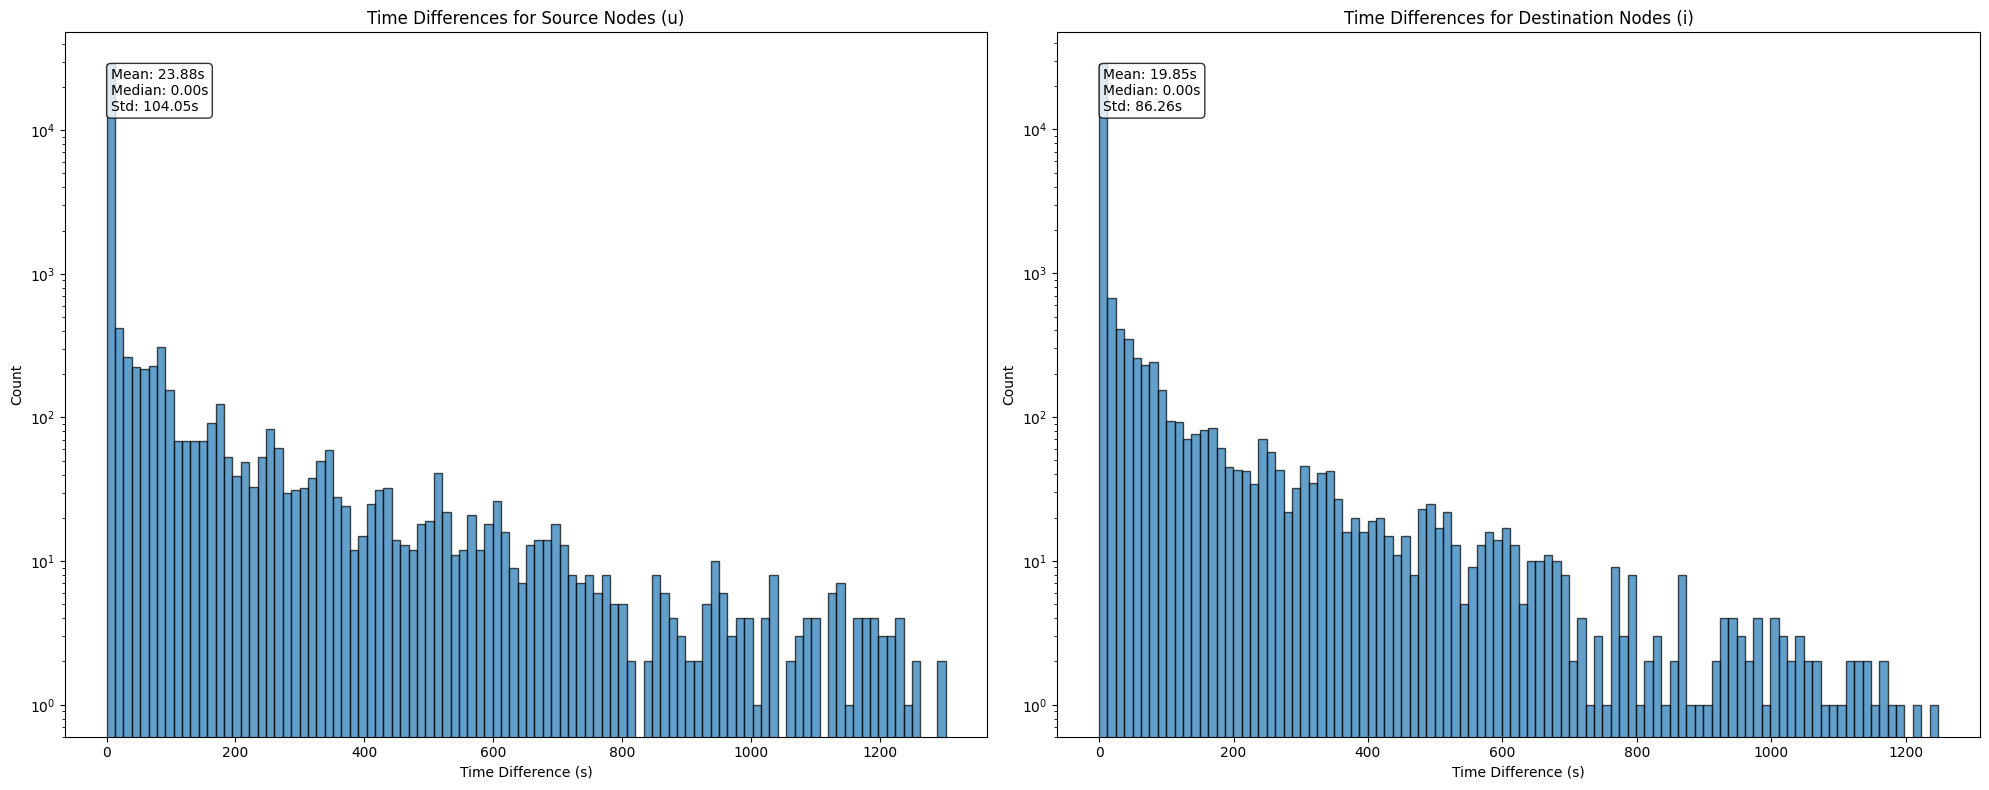

In [43]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

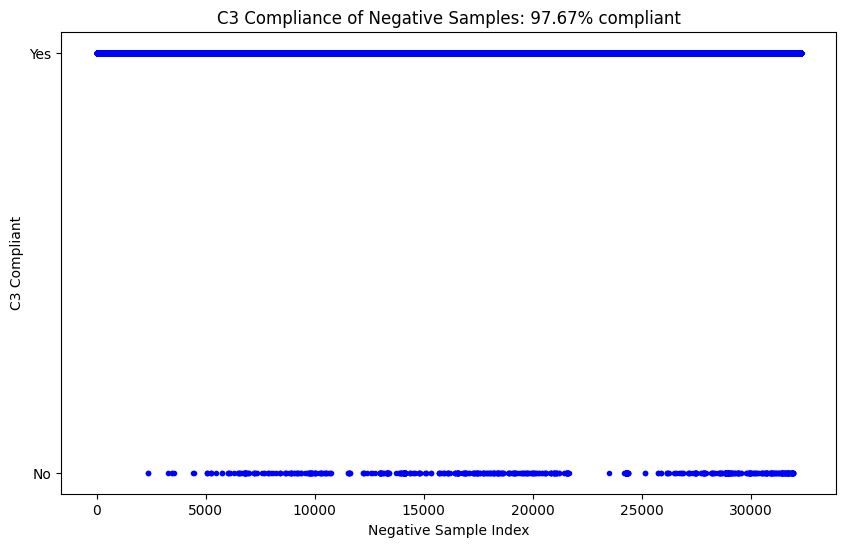

In [45]:
compliant = check_c3_compliance(pd.concat(all_missing_edges_df), new_edges)
# compliant = check_c3_compliance_optimized(pd.concat(all_missing_edges_df), new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'C3 Compliance of Negative Samples: {sum(compliant)/len(compliant)*100:.2f}% compliant')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

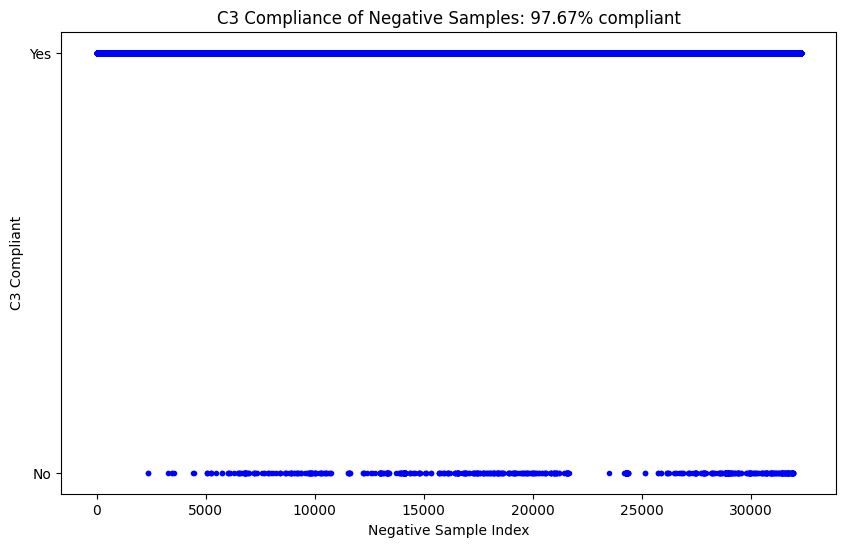

In [44]:
# compliant = check_c3_compliance(pd.concat(all_missing_edges_df), new_edges)
compliant = check_c3_compliance_optimized(pd.concat(all_missing_edges_df), new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'C3 Compliance of Negative Samples: {sum(compliant)/len(compliant)*100:.2f}% compliant')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

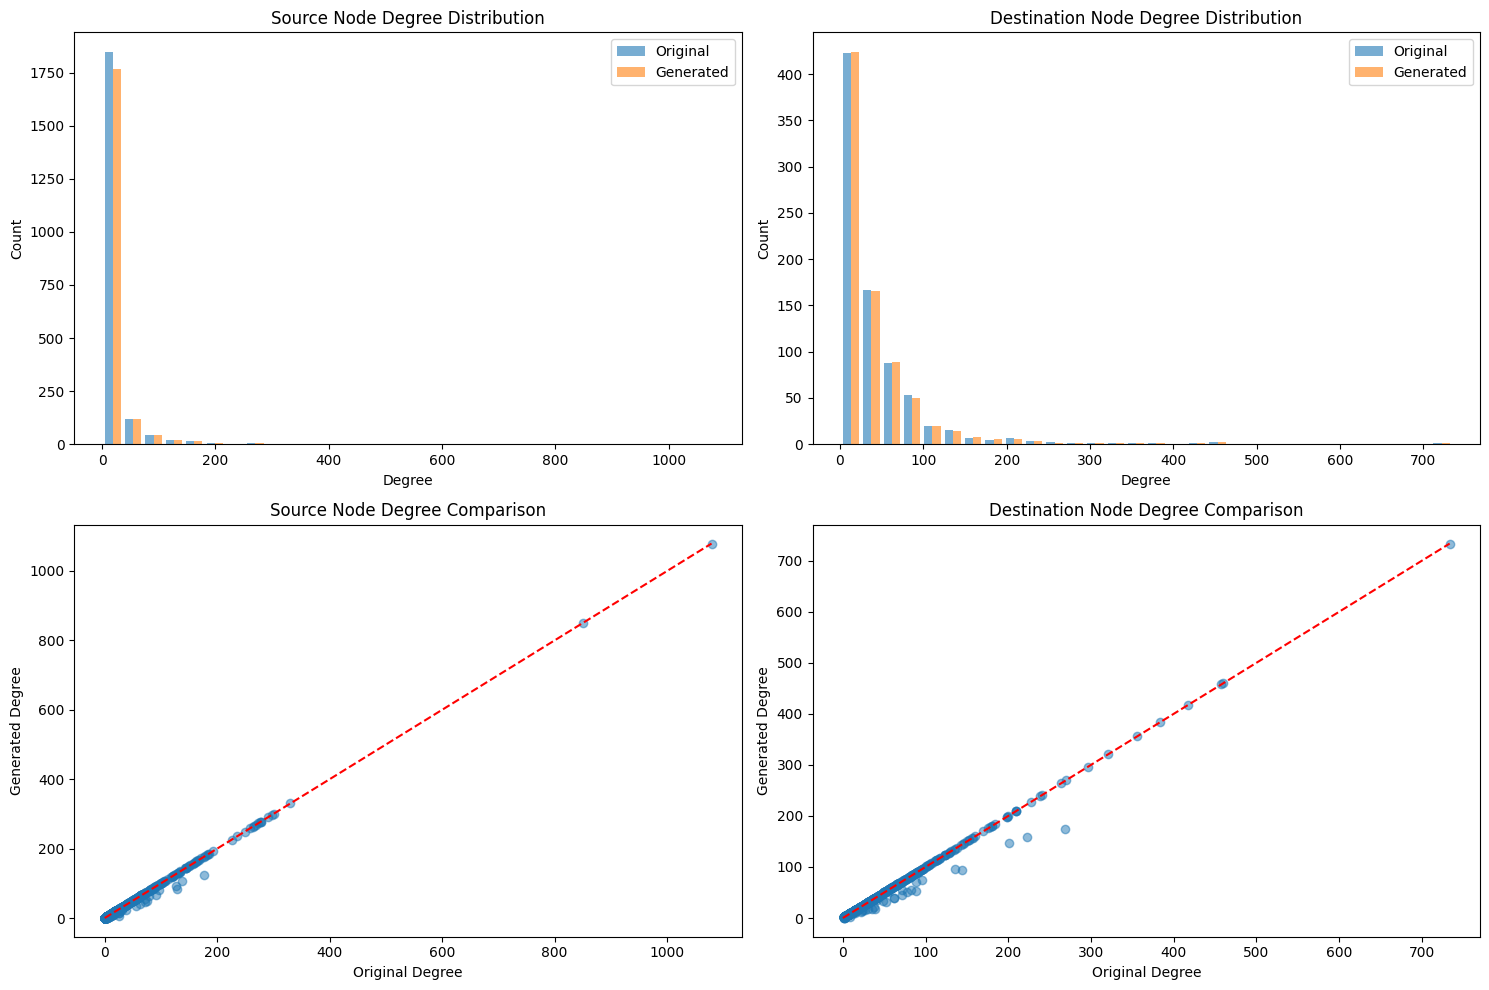

Source degree correlation: nan
Destination degree correlation: 0.995


In [46]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"Source degree correlation: {src_corr:.3f}")
    print(f"Destination degree correlation: {dst_corr:.3f}")
    

# use
plot_degree_comparison(pd.concat(all_missing_edges_df), ns_df)